In [1]:
from pydantic import BaseModel, Field

# Pydantic을 사용한 State 정의
class AgentState(BaseModel):
    user_message: str = Field(default="", description="사용자 입력 작업")
    task_details: str = Field(default="", description="작업 상세 정보")
    response: str = Field(default="", description="응답 결과")

In [2]:
# 노드 함수 정의
def get_llm_response_node(state: AgentState, llm):
    """LLM과 상호작용하여 응답을 생성하거나, 추가 정보를 요청하는 노드"""
    details = state.task_details

    if details:
        print(f"\n상세 정보를 바탕으로 작업 실행: '{details}'")
        prompt = f"다음 요청에 따라 보고서를 작성해주세요: {details}"
    else:
        task = state.user_message
        print(f"\n작업 실행: '{task}' 작업을 수행합니다...")
        # LLM에게 상세 정보를 묻는 질문을 하도록 유도하고, 반드시 '?'로 끝내도록 지시
        prompt = f"'{task}' 작업을 수행하려고 합니다. 어떤 종류의 보고서가 필요한지, 구체적인 주제는 무엇인지 질문해주세요. 추가 정보가 필요하면, 반드시 응답의 마지막을 물음표('?')로 끝내주세요."

    response = llm.invoke(prompt).content

    print("--- LLM 응답 ---")
    print(response)
    print("--------------------")

    return {"response": response, "task_details": ""}

In [3]:
# 사람의 입력을 받는 노드
def get_task_details_node(state: AgentState) -> AgentState:
    """LLM의 질문에 대한 사용자 답변을 입력받는 노드"""
    print("\nLLM의 질문에 답변해주세요.")
    user_input = input("답변: ")
    return {"task_details": user_input}

In [4]:
from typing import Literal

# 조건부 분기 노드
def check_llm_response(state: AgentState) -> Literal["get_details", "end"]:
    """LLM의 응답이 질문인지 확인하여 다음 단계를 결정합니다."""
    print("LLM 응답 분석 중...")
    if state.response.strip().endswith("?"): # 문자열의 끝이 "?"이면 true
        print("LLM이 추가 정보를 요청했습니다. 사용자 입력을 받습니다.")
        return "get_details"
    print("최종 보고서가 생성되었습니다. 워크플로우를 종료합니다.")
    return "end"

In [5]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()

model = ChatGoogleGenerativeAI(model="gemini-2.0-flash")

In [6]:
def get_llm_response_with_llm(state):
        return get_llm_response_node(state, model)

In [7]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(AgentState)
graph_builder.add_node("get_llm_response", get_llm_response_with_llm)
graph_builder.add_node("get_details", get_task_details_node)

graph_builder.add_edge(START, "get_llm_response")
graph_builder.add_conditional_edges(
    "get_llm_response",
    check_llm_response,
    {
        "get_details": "get_details",
        "end": END,
    },
)
graph_builder.add_edge("get_details", "get_llm_response")

In [8]:
graph = graph_builder.compile()

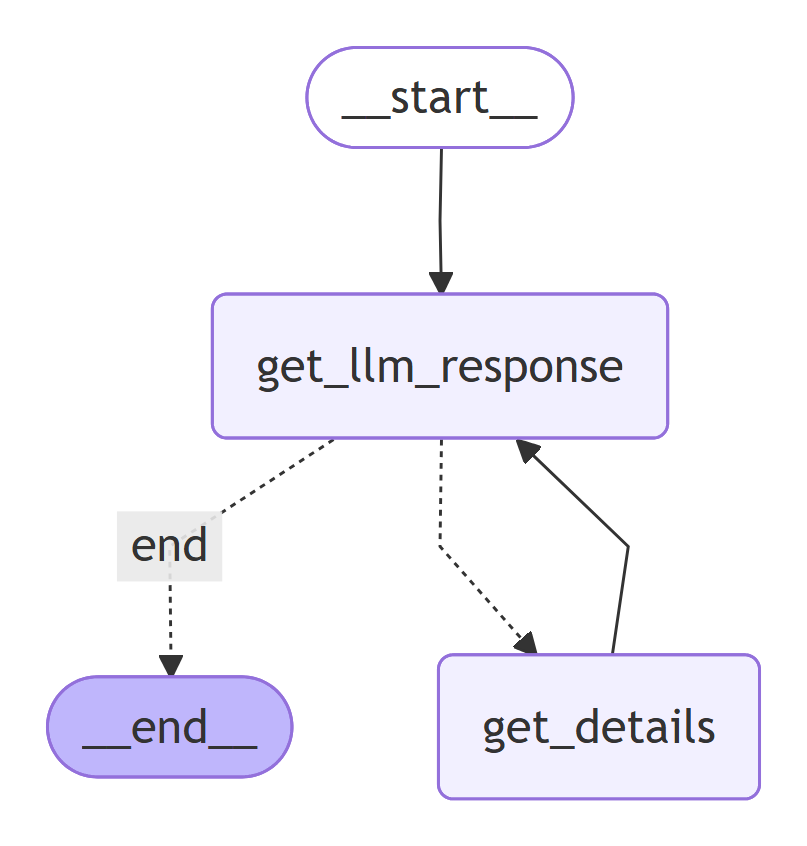

In [9]:
import nest_asyncio
from IPython.display import display, Image
from langchain_core.runnables.graph_mermaid import MermaidDrawMethod

# nest_asyncio를 적용하여 이벤트 루프 중첩 오류를 해결한다.
nest_asyncio.apply()

# (옵션) 그래프를 시각화
# 이 코드는 이미 langchain_core 라이브러리의 pyppeteer.launch()에 
# executablePath가 하드코딩된 상태를 전제로 한다.
display(Image(graph.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER)))

In [10]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [12]:
final_state = graph.invoke(AgentState(user_message="블로그 글 작성"))


작업 실행: '블로그 글 작성' 작업을 수행합니다...
--- LLM 응답 ---
블로그 글 작성 작업에 필요한 보고서는 어떤 종류의 보고서를 말씀하시는 건가요? 예를 들어, 키워드 분석 보고서, 경쟁사 분석 보고서, 독자 분석 보고서 등을 말씀하시는 건가요?

그리고 블로그 글의 구체적인 주제는 무엇인가요? 예를 들어, 특정 제품 리뷰, 여행 후기, 요리 레시피, IT 기술 설명 등 어떤 주제를 원하시는지 알려주세요.

또한, 블로그의 주요 독자층은 누구인가요?

어떤 스타일의 글을 원하시나요? (예: 정보 제공형, 유머러스한, 감성적인 등)

참고 자료나 링크가 있다면 공유해 주실 수 있나요?

원하는 분량은 어느 정도인가요?

SEO 최적화를 고려해야 하나요?

작업 마감일은 언제인가요?

이 외에 특별히 고려해야 할 사항이 있나요?
?
--------------------
LLM 응답 분석 중...
LLM이 추가 정보를 요청했습니다. 사용자 입력을 받습니다.

LLM의 질문에 답변해주세요.

상세 정보를 바탕으로 작업 실행: 'KT 소액 결제 해킹 사건'
--- LLM 응답 ---
## KT 소액 결제 해킹 사건 보고서

**1. 서론**

본 보고서는 KT 소액 결제 시스템에서 발생한 해킹 사건에 대한 배경, 피해 규모, 원인 분석, 대응 과정 및 향후 개선 방안을 종합적으로 분석하여 작성되었습니다. KT 소액 결제는 휴대폰 번호를 이용하여 간편하게 상품 및 서비스를 구매할 수 있는 결제 방식으로, 편리성으로 인해 많은 사용자가 이용하고 있습니다. 하지만 보안 취약점을 악용한 해킹 공격은 사용자들에게 금전적인 피해를 야기할 뿐만 아니라, KT의 신뢰도 하락으로 이어질 수 있습니다. 따라서 본 보고서는 사건의 전반적인 내용을 상세히 파악하고, 유사한 사고의 재발 방지를 위한 실질적인 대책 마련에 기여하고자 합니다.

**2. 사건 개요**

*   **사건 발생 시점:** (정확한 발생 시점 기재 - 예: 2023년 10월 15일 ~ 2023년 10월